# CAC → obstructive lesion — second step

Once a simulant has a CAC value (sampled from the model in
`01_cac_distribution.ipynb`), we attach a probability of having a
>=50% angiographic stenosis. The mapping is a logistic on
`log(CAC + 1)`, anchored to the CONFIRM registry / Budoff JACC 2007
prevalences.

This notebook (a) shows the calibration anchors, (b) demonstrates
end-to-end sampling on a synthetic NHANES-style population, and
(c) reports lesion prevalence by age and sex.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cac_model import sample_cac, CACModelParams
from cad_lesion_model import (
    LesionModelParams,
    prob_obstructive_lesion,
    sample_obstructive_lesion,
    CONFIRM_ANCHORS,
)

rng = np.random.default_rng(20260516)
cac_params = CACModelParams()
lesion_params = LesionModelParams()


## 1. Calibration anchors

Four CONFIRM/Budoff-derived anchors for prevalence of obstructive
coronary disease by CAC category. The default logistic is fit by
least squares; see `cad_lesion_model.fit_default_params()`.


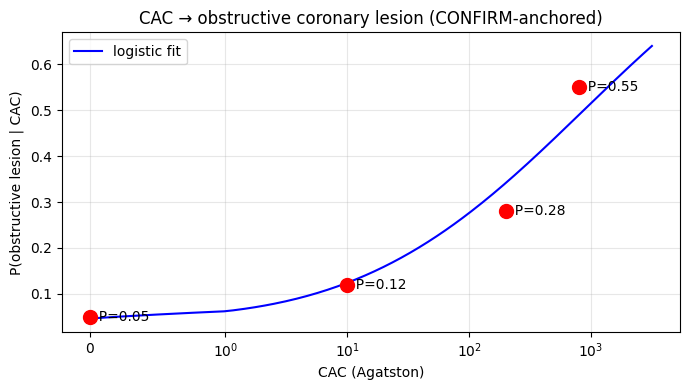

In [2]:
cac_grid = np.logspace(0, 3.5, 200) - 1
p_curve = prob_obstructive_lesion(cac_grid, lesion_params)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cac_grid, p_curve, 'b-', label='logistic fit')
for cac_anchor, p in CONFIRM_ANCHORS.items():
    ax.plot(cac_anchor, p, 'ro', markersize=10)
    ax.annotate(f'  P={p:.2f}', (cac_anchor, p), va='center')
ax.set_xscale('symlog', linthresh=1)
ax.set_xlabel('CAC (Agatston)')
ax.set_ylabel('P(obstructive lesion | CAC)')
ax.set_title('CAC → obstructive coronary lesion (CONFIRM-anchored)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

**Important caveat.** The CONFIRM anchors come from a
*referred* population — patients sick enough to be sent to a cath
lab. Applied to a general-population cohort, the absolute curve
will overstate lesion prevalence. To rescale, lower
`LesionModelParams.offset` by ~0.7-1.0 logits or refit
`CONFIRM_ANCHORS` to general-population targets.


## 2. End-to-end sampling on a synthetic NHANES-style population

We synthesize 5,000 adults aged 40-79 with covariate distributions
loosely matching NHANES 2017-2018 (you can replace this with your
actual simulant table). For each one we:

1. Sample CAC from the two-part log-normal model
2. Sample an obstructive-lesion indicator from the logistic-on-CAC

Both are vectorized, so this scales to millions of simulants.


In [3]:
n = 5000

def synth_population(n, rng):
    age = rng.integers(40, 80, n)
    male = rng.integers(0, 2, n)
    race = rng.choice(['white', 'black', 'chinese', 'hispanic'],
                      size=n, p=[0.62, 0.13, 0.06, 0.19])
    smoke = (rng.random(n) < 0.16).astype(int)
    dm = (rng.random(n) < 0.13).astype(int)
    sbp = rng.normal(126, 16, n)
    bmi = rng.normal(29, 6, n).clip(15, 60)
    tc = rng.normal(195, 38, n).clip(100, 350)
    hdl = rng.normal(52, 15, n).clip(20, 120)
    bp_med = (rng.random(n) < 0.28).astype(int)
    lipid_med = (rng.random(n) < 0.22).astype(int)
    return pd.DataFrame(dict(age=age, male=male, race=race, smoke=smoke,
                             dm=dm, sbp=sbp, bmi=bmi, tc=tc, hdl=hdl,
                             bp_med=bp_med, lipid_med=lipid_med))

pop = synth_population(n, rng)
pop['cac'] = sample_cac(pop, params=cac_params, rng=rng)
pop['p_lesion'] = prob_obstructive_lesion(pop['cac'].to_numpy(), lesion_params)
pop['lesion'] = sample_obstructive_lesion(pop['cac'].to_numpy(), lesion_params, rng=rng)
pop.head(8)

,age,male,race,smoke,dm,sbp,bmi,tc,hdl,bp_med,lipid_med,cac,p_lesion,lesion
0,54,0,white,0,0,108.249023,31.092067,284.374353,53.510834,0,0,13.297600,0.137295,0
1,49,0,white,0,0,106.625322,33.790365,187.108071,51.455756,0,0,0.000000,0.046221,0
2,75,0,black,0,0,136.344196,22.965691,265.600927,75.689653,0,0,948.966812,0.509455,1
3,52,0,white,0,1,99.769206,29.120720,201.020815,42.399042,1,1,0.000000,0.046221,0
4,55,0,black,1,0,126.951932,20.167389,228.628302,61.701371,1,0,0.000000,0.046221,0
5,53,1,black,1,0,135.997228,29.882566,206.292147,56.884117,0,0,0.000000,0.046221,0
6,79,0,hispanic,0,0,126.212777,26.899323,195.449648,54.119071,0,0,123.150712,0.294882,0
7,78,1,white,0,0,140.608935,28.845416,194.453487,42.032725,0,0,392.089460,0.411782,1


## 3. Prevalence by age and sex

Aggregate the sampled cohort. The shape should match what's known
clinically: prevalence climbs sharply with age and is higher in men.


In [4]:
pop['age_bin'] = pd.cut(pop['age'], bins=[40, 50, 60, 70, 80],
                       right=False, labels=['40-49', '50-59', '60-69', '70-79'])

prev = pop.groupby(['age_bin', 'male'], observed=True).agg(
    n=('age', 'size'),
    p_cac_pos=('cac', lambda c: (c > 0).mean()),
    p_cac_geq100=('cac', lambda c: (c >= 100).mean()),
    p_cac_geq400=('cac', lambda c: (c >= 400).mean()),
    p_lesion_mean=('p_lesion', 'mean'),
    p_lesion_obs=('lesion', 'mean'),
).round(3)
prev

n  p_cac_pos  p_cac_geq100  p_cac_geq400  p_lesion_mean  \
age_bin male                                                              
40-49   0     589      0.334         0.087         0.025          0.103   
        1     626      0.559         0.204         0.053          0.162   
50-59   0     612      0.549         0.188         0.062          0.156   
        1     645      0.726         0.343         0.126          0.218   
60-69   0     635      0.767         0.365         0.150          0.232   
        1     623      0.878         0.526         0.258          0.298   
70-79   0     617      0.887         0.501         0.254          0.296   
        1     653      0.940         0.697         0.380          0.368   

              p_lesion_obs  
age_bin male                
40-49   0            0.098  
        1            0.169  
50-59   0            0.126  
        1            0.214  
60-69   0            0.206  
        1            0.295  
70-79   0            0.290  
        1            0.378

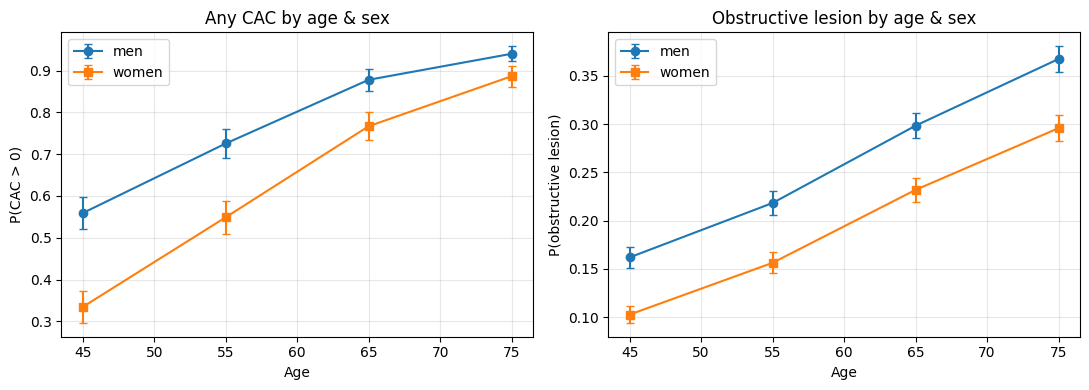

In [5]:
# Plot prevalence by age and sex
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
ages = [45, 55, 65, 75]
for sex_val, marker, lbl in [(1, 'o', 'men'), (0, 's', 'women')]:
    grp = pop[pop['male'] == sex_val].groupby(
        pd.cut(pop[pop['male']==sex_val]['age'],
               bins=[40,50,60,70,80], right=False),
        observed=True,
    )
    pcac = grp['cac'].apply(lambda c: (c > 0).mean()).to_numpy()
    plesion = grp['p_lesion'].mean().to_numpy()
    # use bootstrap CIs around the mean
    pcac_se = grp['cac'].apply(lambda c: np.sqrt((c>0).mean()*(1-(c>0).mean())/len(c))).to_numpy()
    plesion_se = grp['p_lesion'].apply(lambda x: x.std()/np.sqrt(len(x))).to_numpy()

    axes[0].errorbar(ages, pcac, yerr=1.96*pcac_se, marker=marker, capsize=3, label=lbl)
    axes[1].errorbar(ages, plesion, yerr=1.96*plesion_se, marker=marker, capsize=3, label=lbl)

axes[0].set_ylabel('P(CAC > 0)'); axes[0].set_title('Any CAC by age & sex')
axes[1].set_ylabel('P(obstructive lesion)'); axes[1].set_title('Obstructive lesion by age & sex')
for ax in axes:
    ax.set_xlabel('Age')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## 4. Sampling preserves uncertainty

Show the full distribution of CAC at age 60 by sex. The simulation
will get a heavy-tailed log-normal slice, not a point estimate, so
within-cell variability propagates downstream.


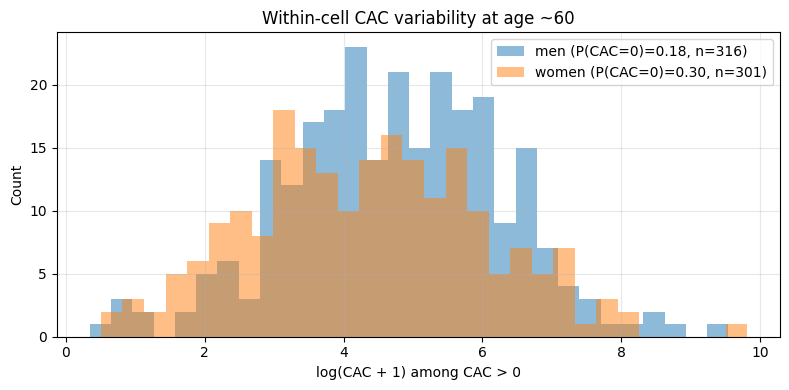

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for sex_val, color, lbl in [(1, 'tab:blue', 'men'), (0, 'tab:orange', 'women')]:
    sample = pop.loc[(pop['age'].between(58, 62)) & (pop['male'] == sex_val), 'cac']
    pos = sample[sample > 0]
    p0 = (sample == 0).mean()
    ax.hist(np.log1p(pos), bins=30, alpha=0.5, color=color,
            label=f'{lbl} (P(CAC=0)={p0:.2f}, n={len(sample)})')
ax.set_xlabel('log(CAC + 1) among CAC > 0')
ax.set_ylabel('Count')
ax.set_title('Within-cell CAC variability at age ~60')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

## 5. Putting it all together

The two-line recipe a simulation can drop in:

```python
from cac_model import sample_cac
from cad_lesion_model import sample_obstructive_lesion

cac = sample_cac(simulants_df, rng=rng)
lesion = sample_obstructive_lesion(cac, rng=rng)
```

Both samplers are vectorized over pandas dataframes / numpy arrays.
Both accept a `params` object so you can refit on better data
without changing call sites.
